In [2]:
import numpy as np
import PKA_Sleep as PKA
import os
import matplotlib.pyplot as plt
from PKA_Sleep import Graphing_Utils as graph
from matplotlib import patches
from neuroscience_sleep_scoring import SWS_utils
from copy import deepcopy
from scipy import stats

In [3]:
import importlib
importlib.reload(PKA.FLPstats)
importlib.reload(PKA)

<module 'PKA_Sleep' from '/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/__init__.py'>

In [33]:
##These parameters are for building the FLP class##
epoch_len = 4
filter_bounds = [None, None] #Add high and low pass cutoffs here if you want to filter the photometry data
binned = False #True or False for using binned vs. unbinned photometry data
shuffle_window = 40 #The size of the chunk used for shuffling the photometry data; usually 200
experimental_sensor = 'FLIM-mAKAR' #label for the sensor used in this experiment (e.g. FLIM-AKAR, FLIM-mAKAR, T391A)
sleep_states = True #True or False - include sleep scores in the class
microarousals = True #True or False - microarousals as a different sleep state
seperate_acqs = False #True or False - Also build a class for each acquisition of an experiment
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_Data' #The directory above the raw data folder
discrete_cutoff = 0.01 #Threshold value for detecting transients
fig_ext = '.png' #type of file that figures made here will save as
region_name = 'mPFC'

In [34]:
EXP_NAMES = ['ltFLiPAKARmemEEGEMG0016',
             'ltFLiPAKARmemEEGEMG0066',
             'ltFLiPAKARmemEEGEMG0071']
MOUSE_ID = ['3825', '4507', '4605']

FLP_classes_dict = PKA.build_classes(EXP_NAMES, MOUSE_ID, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs,
                                     parent_data_directory = parent_data_directory, emp_lifetime = False)

You didn't put any filter values
You didn't put any filter values
You didn't put any filter values


In [6]:
fsd = 400
sound_timestamp_dfs = []
downsample_flag = False
for FLP_exp, b in zip(FLP_classes_dict['Experiment Classes'], FLP_classes_dict['Experiment Names']):
    audio_dir = os.path.join(parent_data_directory, b, b+'_audio', )
    bonsai_timestamp_dir = os.path.join(parent_data_directory, b, b+'_csv')
    if downsample_flag:
        PKA.filter_and_downsample_audio(audio_dir, cutoff_freqs = [8000, 8005], fsd = fsd)
    ts_format = "%m/%d/%Y %H:%M:%S.%f"
    sound_timestamp_df = PKA.get_sound_timestamps(audio_dir, FLP_exp, ts_format = ts_format)
    acq_start_df = PKA.find_photometry_audio_offset(FLP_exp.Timestamps, audio_dir, bonsai_timestamp_dir, adjust = True)
    sound_frames = PKA.find_sound(audio_dir, bonsai_timestamp_dir, sound_timestamp_df, acq_start_df, 
                                  bonsaifile_ts_format = "%Y-%m-%dT%H:%M:%S.%f")
    
    sound_timestamp_df['Detected Sound Window (from acq start)'] = sound_frames
    sound_timestamp_df['Detected Sound Window (from exp start)'] = PKA.soundframes_from_start(FLP_exp, sound_frames)
    sound_timestamp_df['Sound Outcome'] = PKA.sound_result(deepcopy(FLP_exp.SleepStates), FLP_exp.SSTime, 
                                                           sound_timestamp_df['Detected Sound Window (from exp start)'], buffer_window = 8,
                                                          merge_sleep = True)
    sound_timestamp_dfs.append(sound_timestamp_df)

0.107469
adjusting....
0.107469
0.099431
adjusting....
0.099431
0.091853
adjusting....
0.091853
0.082394
adjusting....
0.082394
0.11648
adjusting....
0.11648
0.149197
adjusting....
0.149197
0.181351
adjusting....
0.181351
0.173837
adjusting....
0.173837
0.166887
adjusting....
0.166887
0.199552
adjusting....
0.199552
0.231898
adjusting....
0.231898
0.224423
adjusting....
0.224423
0.256359
adjusting....
0.256359
0.249268
adjusting....
0.249268
0.281754
adjusting....
0.281754
0.314548
adjusting....
0.314548
0.306215
adjusting....
0.306215
0.339354
adjusting....
0.339354
0.371546
adjusting....
0.371546
0.404532
adjusting....
0.404532
1.436762
adjusting....
1.436762
1.42912
adjusting....
1.42912
1.461325
adjusting....
1.461325
1.493824
adjusting....
1.493824
1.526541
adjusting....
1.526541
1.518362
adjusting....
1.518362
1.550989
adjusting....
1.550989
1.542554
adjusting....
1.542554
1.575783
adjusting....
1.575783
1.568538
adjusting....
1.568538
1.601524
adjusting....
1.601524
1.632768
adj

Working on ltFLiPAKARmemEEGEMG0016...
Working on ltFLiPAKARmemEEGEMG0066...
Working on ltFLiPAKARmemEEGEMG0071...


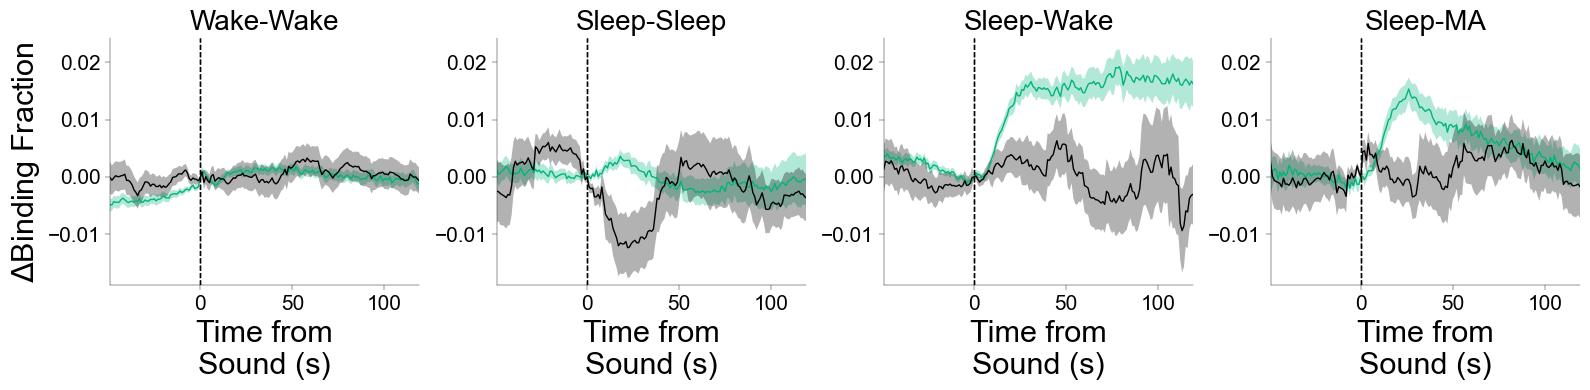

In [35]:
#Set parameters for following plots
window = [50, 120]
state_key = {'Wake': 1, 'Sleep': 2, 'MA': 5}
these_outcomes = ['Wake-Wake', 'Sleep-Sleep', 'Sleep-Wake', 'Sleep-MA']
intensity = False
axes_width = 0.3
shuffled = True
raw_lifetime = False
zscore = False
just_dictionary = False
save_folder = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_2/'
savedir = os.path.join(save_folder, region_name+'_' + experimental_sensor +'_summary'+fig_ext)
color_dict = {k: '#00b47c' for k in these_outcomes}
fig_dict, lifetime_dict = PKA.sound_triggered_lifetime(FLP_classes_dict['Experiment Classes'], FLP_classes_dict['Experiment Names'], 
                                                           sound_timestamp_dfs, window = window, zscore = zscore,
                                                           intensity = intensity, state_key = state_key, these_outcomes = these_outcomes, 
                                                           color_dict = color_dict, axes_width = axes_width, raw_lifetime = raw_lifetime, 
                                                           shuffled = shuffled, just_dictionary = just_dictionary, savedir = savedir)

In [45]:
#Run the stats
all_pvals = {'Reference': 'A_Shuffled'}
these_outcomes = ['Wake-Wake', 'Sleep-Sleep', 'Sleep-Wake', 'Sleep-MA']
amp_windows = {'Wake-Wake': [50, 75],
               'Sleep-Wake': [50, 75],
               'Sleep-MA': [10,30], 
               'Sleep-Sleep':[75, 100]}
slope = False
sleep_slope_win = [30,100]
wake_slope_win = [0,20]
lifetime_dict['Mouse ID'] = MOUSE_ID
quant_dict = PKA.transition_triggered_quant(lifetime_dict, amp_windows, slope = slope)
quant_dict['LFT Quant']['FLIM-mAKAR']['Sleep-Sleep'].append([])
quant_dict['LFT Quant']['Shuffled']['Sleep-Sleep'].append([])

grouped_expnames = [quant_dict['Experiment Name'],quant_dict['Experiment Name']]
grouped_mouseIDs = [quant_dict['Mouse ID'],quant_dict['Mouse ID']]
group_labels = [experimental_sensor, 'Shuffled']

data_categories = quant_dict['LFT Quant'][experimental_sensor].keys()
all_results = {}
for c in data_categories:
    grouped_data = [
        quant_dict['LFT Quant'][experimental_sensor][c],
        quant_dict['LFT Quant']['Shuffled'][c]
    ]
    stage1_df, perm_result, welch_result = PKA.nested_analysis_stats_v2(
        grouped_data, grouped_expnames, grouped_mouseIDs, group_labels, perm_flag = True, paired=True)
    all_results[c] = {
        'stage1': stage1_df,
        'perm': perm_result,
        'welch': welch_result
    }

Working on Wake-Wake
Working on Sleep-Wake
Working on Sleep-MA
Working on Sleep-Sleep
Working on Wake-Wake
Working on Sleep-Wake
Working on Sleep-MA
Working on Sleep-Sleep
Stage 1: Computing robust subject-level means using HuberT...
  Processed 6 subject-group combinations
  Observations with downweighted data: 2

=== Stage 1: per-animal robust means ===
Mouse_ID      Group  robust_mean  robust_se  n_obs
    3825 FLIM-mAKAR     0.000431   0.000980     18
    3825   Shuffled    -0.008484   0.003671     18
    4507 FLIM-mAKAR     0.001218   0.001334     21
    4507   Shuffled     0.006112   0.005855     21
    4605 FLIM-mAKAR    -0.002162   0.000670     30
    4605   Shuffled     0.003729   0.003675     30

=== Stage 2 (PRIMARY): sign permutation, 8 arrangements ===
  Mean diff (FLIM-mAKAR - Shuffled): -0.0006
  p (two-tailed) = 1.0000  [minimum possible = 0.2500]

=== Stage 2 (SECONDARY): paired t-test ===
  t(2) = -0.130, p = 0.9081, Cohen's dz = -0.08
Stage 1: Computing robust subjec

/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:522: RuntimeWarning: Mean of empty slice
  quant.append(np.nanmean(l[averaging_window]))


In [49]:
all_results['Sleep-Sleep']['welch']['p_t']

np.float64(0.5666449313345442)